$$
TxReal = \Bigg(\dfrac{(1 + i)(1+IPCA)^n - \big((1+i)(1+IPCA)^n - 1 \big)*IR}{(1+IPCA)^n} \Bigg)^{1/n} - 1
$$

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt


def amort_calculator(p, i, n):
    return p*i*(1+i)**n/((1+i)**n-1)


def future_value_with_payments(payment, ir, n):
    return (payment * (1+ir) ** n - 1)/ir


def future_value_from_amt(amt, ir, n):
    return amt*(1+ir)**n


def deflator(inflacao, n):
    return (1+inflacao)**n


def taxa_real_com_ir(i, inflacao, ir, n):
    valor_final = ((1+i)*(1+inflacao))**n
    rendimento = valor_final - 1
    deflator = (1+inflacao)**n
    
    return ((valor_final - rendimento*ir)/deflator)**(1/n)-1


In [10]:
dados = pd.DataFrame(dict(
    inflacao = np.linspace(0, 0.5),
    juros = 0.06,
    imposto = 0.15,
    key=1
)).merge(
    pd.DataFrame(dict(anos=[5, 10, 15, 20], key=1))
).drop(columns=["key"])


dados["tx_real"] = taxa_real_com_ir(i=0.06, inflacao=dados["inflacao"], ir=0.15, n=dados["anos"])*100

dados

,inflacao,juros,imposto,anos,tx_real
0,0.000000,0.06,0.15,5,5.183808
1,0.000000,0.06,0.15,10,5.275995
2,0.000000,0.06,0.15,15,5.355587
3,0.000000,0.06,0.15,20,5.424108
4,0.010204,0.06,0.15,5,5.062220
...,...,...,...,...,...
195,0.489796,0.06,0.15,20,5.142240
196,0.500000,0.06,0.15,5,2.963916
197,0.500000,0.06,0.15,10,4.309030
198,0.500000,0.06,0.15,15,4.858907


Text(0.5, 1.0, 'Rendimento de 6% a.a. + Inflação com 15% de IR')

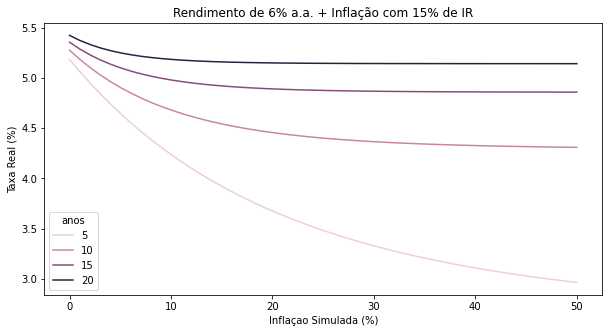

In [18]:
plt.figure(figsize=(10, 5))

sns.lineplot(data=dados.assign(inflacao=lambda d: d["inflacao"]*100), x="inflacao", y="tx_real", hue="anos")

plt.ylabel("Taxa Real (%)");
plt.xlabel("Inflaçao Simulada (%)");
plt.title("Rendimento de 6% a.a. + Inflação com 15% de IR")